In [113]:
import pandas as pd
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("..//data//train_data.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           9864 non-null   int64  
 1   Administrative_Duration  9864 non-null   float64
 2   Informational            9864 non-null   int64  
 3   Informational_Duration   9864 non-null   float64
 4   ProductRelated           9864 non-null   int64  
 5   ProductRelated_Duration  9864 non-null   float64
 6   BounceRates              9864 non-null   float64
 7   ExitRates                9864 non-null   float64
 8   PageValues               9864 non-null   float64
 9   SpecialDay               9864 non-null   float64
 10  Month                    9864 non-null   object 
 11  OperatingSystems         9864 non-null   int64  
 12  Browser                  9864 non-null   int64  
 13  Region                   9864 non-null   int64  
 14  TrafficType             

In [4]:
x = data.drop(columns=["Revenue"])
y = data["Revenue"]

In [5]:
categorical_features = ['Month','VisitorType']
numerical_features = [
    'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
    'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType'
]

In [28]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', MinMaxScaler(), numerical_features)
])

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
x_pre = preprocessor.fit(x_train).transform(x_train)

In [31]:
x_val = preprocessor.transform(x_test)

In [120]:
ct_ft=preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_ft = list(ct_ft) + numerical_features
x_pre = pd.DataFrame(x_pre, columns=all_ft)
x_val = pd.DataFrame(x_val, columns=all_ft)

In [121]:
model =  XGBClassifier(
    n_estimators=50,
    learning_rate=0.05,
    objective='binary:logistic',
    eval_metric='auc',
    max_depth=4,
    subsample=0.3,
    scale_pos_weight=4
)

In [122]:
model.fit(x_pre, y_train)
y_pred = model.predict(x_val)

In [123]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.95      0.89      0.92      1669
        True       0.55      0.75      0.64       304

    accuracy                           0.87      1973
   macro avg       0.75      0.82      0.78      1973
weighted avg       0.89      0.87      0.88      1973



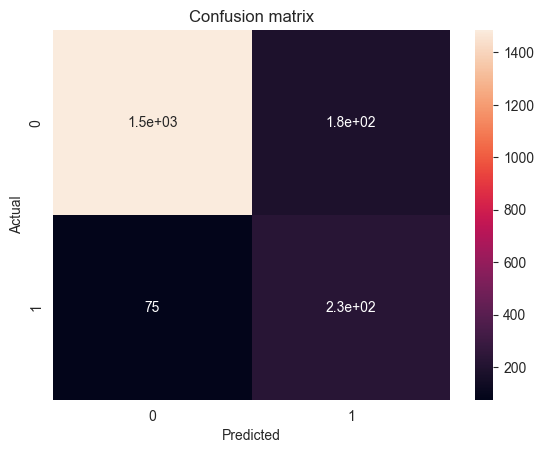

In [124]:

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()

the model performance is a sign that many customers may not complete their purchase on their first session for a product they are interseted in buying, as they may want to do some more research on that product and may come later and finish the transcation in a different session.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

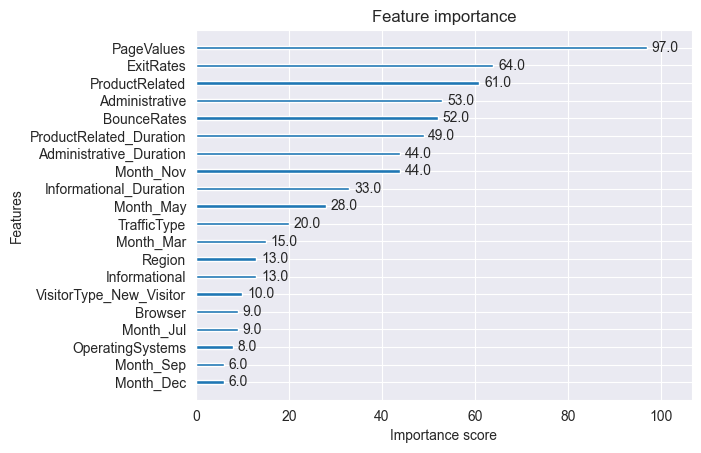

In [128]:
xgb.plot_importance(model, max_num_features=20)

In [199]:
cols  = ['PageValues', 'ExitRates', 'ProductRelated', 'Administrative', 'BounceRates', 'ProductRelated_Duration', 'Administrative_Duration', 'Month', 'Informational_Duration']

In [200]:
categorical_features = ['Month']
numerical_features = [i for i in cols if i not in categorical_features]

In [201]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', MinMaxScaler(), numerical_features)
])

In [202]:
x = data[cols]
y = data['Revenue']

In [203]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [204]:
x_pre = preprocessor.fit(x_train).transform(x_train)

In [205]:
x_val = preprocessor.transform(x_test)

In [206]:
ct_ft=preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_ft = list(ct_ft) + numerical_features
x_pre = pd.DataFrame(x_pre, columns=all_ft)
x_val = pd.DataFrame(x_val, columns=all_ft)

In [207]:
model =  XGBClassifier(
    n_estimators=75,
    learning_rate=0.05,
    objective='binary:logistic',
    eval_metric='auc',
    max_depth=3,
    subsample=0.3,
    scale_pos_weight=3
)

In [208]:
model.fit(x_pre, y_train)
y_pred = model.predict(x_val)

In [209]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.95      0.90      0.93      1669
        True       0.58      0.72      0.64       304

    accuracy                           0.88      1973
   macro avg       0.76      0.81      0.78      1973
weighted avg       0.89      0.88      0.88      1973



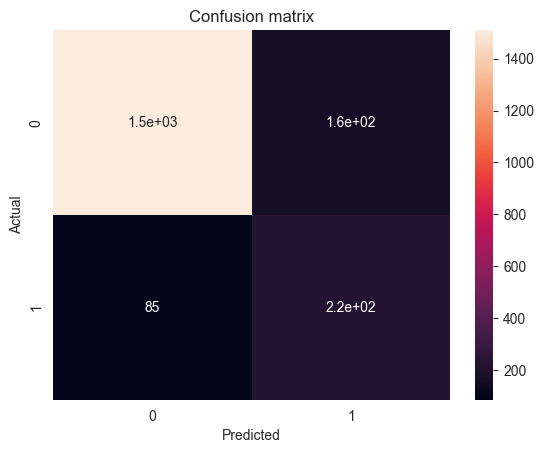

In [210]:

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()

In [186]:
accuracy_score(y_test, y_pred)

0.8763304612265586